# Stage 5A — Post-Test Deep Tabular Models

## Stage 5A1 — Deep Foundation and Core Screening

### 0. Stage 5A1 Objective

This Stage checks three maintained Deep families on one frozen Train-only sample. It stops after two families are selected. The limitation is that this is Screening, not Final Validation.

In [1]:
print('Objective: six non-sensitive Discovery fits; no Test, sensitive, full-Train, Stage 5A2, or TabR work.')

Objective: six non-sensitive Discovery fits; no Test, sensitive, full-Train, Stage 5A2, or TabR work.


### 1. Imports and Configuration

This cell imports only reporting tools. It does not import a training worker. The conclusion is that presentation execution cannot retrain a model.

In [2]:
from pathlib import Path
import json, pandas as pd
ROOT = Path.cwd()
print({'stage_id':'stage5a1','schema':'deep_core_v1','presentation_mode':'saved_artifacts_only'})

{'stage_id': 'stage5a1', 'schema': 'deep_core_v1', 'presentation_mode': 'saved_artifacts_only'}


### 2. Previous-Stage Verification

Previous Gates must pass before Deep Screening is trusted. This compact output shows real saved status; it does not repeat prior work.

In [3]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_start_validation.json').read_text())
print(d['status'], d['prior_stage_statuses'])

PASS {'prompt1_verification.json': 'PASS', 'prompt2_verification.json': 'PASS', 'stage3_verification.json': 'PASS', 'stage4a_verification.json': 'PASS', 'stage4b_verification.json': 'PASS', 'stage4c_verification.json': 'PASS', 'stage4de_verification.json': 'PASS', 'stage4f_gate_verification.json': 'PASS', 'stage4g_gate_verification.json': 'PASS', 'stage4h_verification.json': 'PASS', 'stage4i_gate_verification.json': 'PASS', 'stage4j_gate_verification.json': 'PASS', 'stage4k_verification.json': 'PASS', 'stage4l_verification.json': 'PASS'}


### 3. Post-Test Governance

Stage 4L consumed Test, so no Test evidence can guide Deep development. This Stage used only Train Discovery roles. A new independent holdout is needed for another unbiased final evaluation.

In [4]:
print({'post_test_extension':True,'test_rows_loaded':0,'stage4l_test_metrics_used':False})

{'post_test_extension': True, 'test_rows_loaded': 0, 'stage4l_test_metrics_used': False}


### 4. Protected File Baseline

Protected hashes guard source data, old Notebooks, splits, prior models, and Stage 4L artifacts. Stage 5 Registry rows are allowed only when the prior byte prefix stays unchanged.

In [5]:
d=json.loads((ROOT/'artifacts/manifests/stage5/stage5a1_protected_hashes_before.json').read_text())
print({'status':d['status'],'protected_files':d['protected_file_count']})

{'status': 'PASS', 'protected_files': 204}


### 5. Deep Environment Audit

Authentic package versions and the safe device are recorded. CUDA is unavailable in this PyTorch build, so CPU float32 is the supported conclusion.

In [6]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_environment_report.json').read_text())
print({'status':d['status'],'packages':d['packages'],'device':d['selected_device'],'amp':d['amp']})

{'status': 'PASS', 'packages': {'joblib': {'import_status': 'PASS', 'version': '1.5.3'}, 'matplotlib': {'import_status': 'PASS', 'version': '3.11.0'}, 'numpy': {'import_status': 'PASS', 'version': '2.5.1'}, 'pandas': {'import_status': 'PASS', 'version': '3.0.3'}, 'psutil': {'import_status': 'PASS', 'version': '7.2.2'}, 'pytabkit': {'import_status': 'PASS', 'version': '1.7.3'}, 'rtdl-num-embeddings': {'import_status': 'PASS', 'version': '0.0.12'}, 'rtdl-revisiting-models': {'import_status': 'PASS', 'version': '0.0.2'}, 'scikit-learn': {'import_status': 'PASS', 'version': '1.9.0'}, 'tabm': {'import_status': 'PASS', 'version': '0.0.3'}, 'torch': {'import_status': 'PASS', 'version': '2.13.0'}}, 'device': 'cpu', 'amp': False}


### 6. CPU and CUDA Smoke Test

The smoke test used at most 4,000/1,000 rows and three epochs. All three families completed CPU forward, backward, optimizer, prediction, and reload checks. CUDA and AMP remain unavailable, not silently emulated.

In [7]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_hardware_smoke.json').read_text())
print(d['status'], d['checks'])

PASS {'amp_smoke': 'NOT_RUN_CPU_BUILD', 'cpu_forward_backward_optimizer': True, 'cuda_available': False, 'cuda_smoke': 'NOT_RUN_CPU_BUILD', 'epoch_budget_valid': True, 'finite_predictions': True, 'row_budget_valid': True, 'save_reload': True}


### 7. Discovery Sample Validation

The exact saved roles are reused without resampling. The result is 50,000 Train and 15,000 Validation rows with zero Test overlap.

In [8]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_start_validation.json').read_text())
print(d['role_counts'], d['checks']['discovery_test_overlap_zero'])

{'train': 50000, 'validation': 15000} True


### 8. Deep Feature Schema

`deep_core_v1` contains safe numeric, categorical, and approved engineered fields. Audit IDs, target bins, sensitive fields, duplicate codes, and the target are excluded.

In [9]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_feature_schema.json').read_text())
print({'numeric':len(d['numerical_features']),'categorical':len(d['categorical_features']),'digest':d['feature_schema_digest']})

{'numeric': 16, 'categorical': 15, 'digest': '0da7589e158882d8b4a8df0d69a93212d6d86f52e163425d573e6629ddb65c1a'}


### 9. Embedding and Cardinality Audit

Training-only cardinalities estimate embedding cost before training. The saved estimate is small enough for the bounded architectures; this does not prove later full-sample memory use.

In [10]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_feature_schema.json').read_text())
print(d['high_cardinality_audit'], d['estimated_embedding_memory_bytes_float32'])

{'county_name': 749, 'msamd_name': 368, 'respondent_id': 2566} 189552


### 10. Common Data Safety

Every preprocessor uses working copies, training-only learned values, stable order, unknown tokens, and finite float32 tensors. Validation rows are transform-only.

In [11]:
v=pd.read_csv(ROOT/'artifacts/reports/stage5a1_preprocessing_verification.csv')
print(v[['family','validation_rows_seen_during_fit','source_frame_unchanged','finite_output','status']].to_string(index=False))

        family  validation_rows_seen_during_fit  source_frame_unchanged  finite_output status
       realmlp                                0                    True           True   PASS
          tabm                                0                    True           True   PASS
ft_transformer                                0                    True           True   PASS


### 11. RealMLP Preprocessing

RealMLP gets median-imputed numeric fields and sanitized categories, then uses official tuned internal preprocessing without a duplicate scaler.

In [12]:
v=pd.read_csv(ROOT/'artifacts/reports/stage5a1_preprocessing_verification.csv')
print(v[v.family=='realmlp'].to_string(index=False))

 family  fit_rows  validation_rows_seen_during_fit  source_frame_unchanged  finite_output  unknown_category_handled  serialization_match                                                                      artifact status
realmlp     50000                                0                    True           True                      True                 True artifacts\preprocessing\stage5\deep_core\stage5a1_realmlp_preprocessor.joblib   PASS


### 12. TabM Preprocessing

TabM uses training vocabularies with Missing, Unknown, and Rare tokens, learned per-feature categorical embeddings, and training-fit piecewise-linear numeric bins. The binary feature warning means one bin acts like min-max scaling.

In [13]:
v=pd.read_csv(ROOT/'artifacts/reports/stage5a1_preprocessing_verification.csv')
print(v[v.family=='tabm'].to_string(index=False))
print(json.loads((ROOT/'artifacts/reports/stage5a1_repair_smoke.json').read_text())['tabm_architecture'])

family  fit_rows  validation_rows_seen_during_fit  source_frame_unchanged  finite_output  unknown_category_handled  serialization_match                                                                   artifact status
  tabm     50000                                0                    True           True                      True                 True artifacts\preprocessing\stage5\deep_core\stage5a1_tabm_preprocessor.joblib   PASS
{'arch_type': 'tabm', 'categorical_embedding_dimension': 16, 'categorical_input': 'learned torch.nn.Embedding per feature', 'd_block': 256, 'dropout': 0.1, 'implementation': 'tabm.make_tabm_backbone with torch.nn.Embedding input module', 'k': 16, 'maintained_public_tabm_api': True, 'n_blocks': 2, 'num_embedding': 'PiecewiseLinearEmbeddings version B', 'num_embedding_dimension': 16, 'numeric_bin_count': 48}


### 13. FT-Transformer Preprocessing

FT-Transformer uses a training-fit normal quantile transform and categorical embeddings. RTDL then performs true feature tokenization.

In [14]:
v=pd.read_csv(ROOT/'artifacts/reports/stage5a1_preprocessing_verification.csv')
print(v[v.family=='ft_transformer'].to_string(index=False))

        family  fit_rows  validation_rows_seen_during_fit  source_frame_unchanged  finite_output  unknown_category_handled  serialization_match                                                                             artifact status
ft_transformer     50000                                0                    True           True                      True                 True artifacts\preprocessing\stage5\deep_core\stage5a1_ft_transformer_preprocessor.joblib   PASS


### 14. Preprocessing Serialization Tests

All preprocessors reload with matching outputs and handle an unseen category. This verifies the small preprocessing probe, not every future input distribution.

In [15]:
v=pd.read_csv(ROOT/'artifacts/reports/stage5a1_preprocessing_verification.csv')
print(v[['family','unknown_category_handled','serialization_match','status']].to_string(index=False))

        family  unknown_category_handled  serialization_match status
       realmlp                      True                 True   PASS
          tabm                      True                 True   PASS
ft_transformer                      True                 True   PASS


### 15. Screening Plan

The final valid set has two target modes for each family. Four approved family repairs and one strict RealMLP protocol repair produced eleven preserved physical fits. Five invalid or non-compliant artifacts remain superseded audit evidence.

In [16]:
print(json.loads((ROOT/'artifacts/reports/stage5a1_screening_validity.json').read_text()))

{'approved_replacement_fit_count': 5, 'final_valid_candidate_count': 6, 'four_family_repair_fit_count': 4, 'historical_artifacts_preserved': True, 'initial_fit_count': 6, 'physical_screening_fit_count': 11, 'protocol_repair_fit_count': 1, 'status': 'PASS', 'superseded_candidates': {'stage5a1__realmlp__log1p': 'stage5a1__realmlp__log1p__replacement1', 'stage5a1__realmlp__log1p__replacement1': 'stage5a1__realmlp__log1p__replacement2', 'stage5a1__realmlp__raw': 'stage5a1__realmlp__raw__replacement1', 'stage5a1__tabm__log1p': 'stage5a1__tabm__log1p__replacement1', 'stage5a1__tabm__raw': 'stage5a1__tabm__raw__replacement1'}, 'valid_candidate_ids': ['stage5a1__ft_transformer__log1p', 'stage5a1__ft_transformer__raw', 'stage5a1__realmlp__log1p__replacement2', 'stage5a1__realmlp__raw__replacement1', 'stage5a1__tabm__log1p__replacement1', 'stage5a1__tabm__raw__replacement1']}


### 16. RealMLP Screening

RealMLP raw and the strict epoch-64 log1p repair use the unchanged Train-only vocabularies. The serialized log1p model proves best-checkpoint restoration was disabled; raw wins the family by 1.818% Validation MAE.

In [17]:
r=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/screening/stage5a1_screening_results.csv')
print(r[r.model_family=='realmlp'][['candidate_id','target_mode','mae','rmse','rmsle','top_decile_mae','fit_time_seconds','best_epoch','epochs_completed']].to_string(index=False))
print(json.loads((ROOT/'artifacts/reports/stage5a1_realmlp_log1p_fit11_independent_validation.json').read_text())['checks'])

                          candidate_id target_mode       mae       rmse    rmsle  top_decile_mae  fit_time_seconds  best_epoch  epochs_completed
stage5a1__realmlp__log1p__replacement2       log1p 66.015215 136.803117 0.412799      201.837202        326.662747          64              64.0
  stage5a1__realmlp__raw__replacement1         raw 64.836652 139.650959 0.407200      204.053575        121.604497          30               NaN
{'candidate_status_pass': True, 'clean_reload_pass': True, 'completed_epochs_64': True, 'early_stopping_disabled': True, 'historical_artifacts_unchanged': True, 'history_final_epoch_64': True, 'history_length_64': True, 'internal_use_best_epoch_false': True, 'official_stop_epoch_64': True, 'physical_fit_number_11': True, 'progress_max_epochs_64': True, 'reload_predictions_match': True, 'requested_epochs_64': True, 'restored_checkpoint_epoch_null': True, 'saved_artifact_epoch_64': True, 'test_rows_zero': True, 'train_only_encoder': True, 'use_best_epoch_false'

### 17. TabM Screening

TabM raw clearly beats log1p on MAE, RMSE, and tail error. Raw is the family winner despite its small negative-prediction rate.

In [18]:
r=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/screening/stage5a1_screening_results.csv')
print(r[r.model_family=='tabm'][['target_mode','mae','rmse','rmsle','top_decile_mae','negative_prediction_rate']].to_string(index=False))

target_mode       mae       rmse    rmsle  top_decile_mae  negative_prediction_rate
      log1p 66.526229 145.793434 0.403303      234.172886                  0.000000
        raw 66.123240 139.866713 0.453631      209.413228                  0.001533


### 18. FT-Transformer Screening

FT log1p improves primary MAE and becomes the family winner. Raw has better tail MAE, which remains an important Stage 5A2 limitation.

In [19]:
r=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/screening/stage5a1_screening_results.csv')
print(r[r.model_family=='ft_transformer'][['target_mode','mae','rmse','rmsle','top_decile_mae','negative_prediction_rate']].to_string(index=False))

target_mode       mae       rmse    rmsle  top_decile_mae  negative_prediction_rate
      log1p 65.279835 138.501950 0.410617      215.807735                    0.0000
        raw 65.950237 137.685839 0.436009      194.708712                    0.0026


### 19. Six-Candidate Results

Exactly six Candidate rows are present. All metrics are on the original target scale, and no Test row appears.

In [20]:
r=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/screening/stage5a1_screening_results.csv')
print(r[['candidate_id','mae','rmse','rmsle','top_decile_mae','fit_time_seconds']].sort_values('mae').to_string(index=False))
print('count',len(r))

                          candidate_id       mae       rmse    rmsle  top_decile_mae  fit_time_seconds
  stage5a1__realmlp__raw__replacement1 64.836652 139.650959 0.407200      204.053575        121.604497
       stage5a1__ft_transformer__log1p 65.279835 138.501950 0.410617      215.807735        546.903049
         stage5a1__ft_transformer__raw 65.950237 137.685839 0.436009      194.708712        701.492123
stage5a1__realmlp__log1p__replacement2 66.015215 136.803117 0.412799      201.837202        326.662747
     stage5a1__tabm__raw__replacement1 66.123240 139.866713 0.453631      209.413228        349.118082
   stage5a1__tabm__log1p__replacement1 66.526229 145.793434 0.403303      234.172886        371.662299
count 6


### 20. Family Winners

One winner is saved for every mandatory family. These are Discovery winners and are not final models.

In [21]:
w=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/screening/stage5a1_family_winners.csv')
print(w[['model_family','candidate_id','mae','top_decile_mae','selection_reason']].to_string(index=False))

  model_family                         candidate_id       mae  top_decile_mae                                              selection_reason
       realmlp stage5a1__realmlp__raw__replacement1 64.836652      204.053575 Selected lower Validation MAE; pair gap 1.818% exceeds 0.25%.
ft_transformer      stage5a1__ft_transformer__log1p 65.279835      215.807735 Selected lower Validation MAE; pair gap 1.027% exceeds 0.25%.
          tabm    stage5a1__tabm__raw__replacement1 66.123240      209.413228 Selected lower Validation MAE; pair gap 0.609% exceeds 0.25%.


### 21. Top-Two Family Selection

RealMLP has the best winner MAE. FT-Transformer beats TabM by 1.292%, outside the 0.5% tie band, so RealMLP and FT-Transformer continue. TabM remains fully preserved.

In [22]:
d=json.loads((ROOT/'artifacts/results/stage5/deep_core/screening/stage5a1_top_two_families.json').read_text())
print(d)

{'family_winners_preserved': ['stage5a1__realmlp__raw__replacement1', 'stage5a1__ft_transformer__log1p', 'stage5a1__tabm__raw__replacement1'], 'feature_schema': 'deep_core_v1', 'not_selected_family': 'tabm', 'selected_candidate_ids': ['stage5a1__realmlp__raw__replacement1', 'stage5a1__ft_transformer__log1p'], 'selected_families': ['realmlp', 'ft_transformer'], 'selection_reason': 'realmlp has the best family-winner MAE. The remaining-family MAE gap is 1.292%; lower MAE wins.', 'stage_id': 'stage5a1', 'status': 'PASS', 'test_evidence_used': False}


### 22. Stage 5A1 Artifact Summary

The summary confirms eleven physical fits, exactly six valid Candidates, three winners, two selected families, and a unique Registry. Saved artifacts allow safe resume without refitting.

In [23]:
d=json.loads((ROOT/'artifacts/reports/stage5a1_screening_summary.json').read_text())
print(d)

{'approved_replacement_fit_count': 5, 'family_winner_count': 3, 'physical_screening_fit_count': 11, 'protocol_repair_fit_count': 1, 'registry': {'action': 'REUSED', 'prior_byte_prefix_preserved': True, 'prior_row_count': 299, 'registry_ids_unique': True, 'registry_row_count': 315, 'stage5a1_row_count': 16, 'status': 'PASS'}, 'screening_fit_count': 6, 'selected_families': ['realmlp', 'ft_transformer'], 'selected_family_count': 2, 'status': 'PASS'}


### 23. Stage 5A1 Gate Verification

The Notebook loads final Gate evidence when available; otherwise it shows the pre-review Gate. Reviewer completion is required before final PASS.

In [24]:
p=ROOT/'artifacts/reports/stage5a1_gate_verification.json'
if not p.exists(): p=ROOT/'artifacts/reports/stage5a1_pre_review_verification.json'
d=json.loads(p.read_text())
print({'phase':d.get('phase','final'),'status':d['status'],'checks':d['checks']})

{'phase': 'final', 'status': 'PASS', 'checks': {'clean_process_reload_pass': True, 'defective_reason_exact': True, 'exactly_six_valid_candidates': True, 'exactly_two_continuing_families': True, 'fit11_early_stopping_disabled': True, 'fit11_history_64': True, 'fit11_independent_validation_pass': True, 'fit11_no_checkpoint_restoration': True, 'fit11_protocol_proof_pass': True, 'fit11_requested_and_completed_64': True, 'fit11_saved_epoch_64': True, 'fit11_use_best_epoch_false': True, 'full_train_fit_count_zero': True, 'historical_fit_artifacts_preserved': True, 'notebook_attempt2_pass_zero_retraining': True, 'notebook_saved_artifacts_only_source': True, 'physical_fit_count_11': True, 'pre_review_verification_pass': True, 'protected_recheck_pass': True, 'raw_log_for_all_three_families': True, 'registry_idempotent_and_prior_prefix_preserved': True, 'reviewer_cycle3_pass': True, 'sensitive_fit_count_zero': True, 'stage5a2_stage5b_tabr_not_started': True, 'test_rows_zero': True, 'train_only_v

### 24. Stage 5A1 Completion Note

Stage 5A1 ends after top-two selection. It does not start Stage 5A2 or claim an unbiased Deep Test result.

In [25]:
p=ROOT/'artifacts/reports/stage5a1_gate_verification.json'
print('Next Step: Begin Stage 5A2 — Top-Two Deep Validation and Core Final Models.' if p.exists() else 'Pending independent Reviewer and final Gate verification.')

Next Step: Begin Stage 5A2 — Top-Two Deep Validation and Core Final Models.


### 25. Stage 5A2 Objective and Governance

Stage 5A2 is a post-Test extension. It uses saved Train-only scientific evidence. A loader parsed complete source chunks before applying the Train-only row mask, so requested Test-row Feature and target values were temporarily in memory. This violated the literal no-Test-loading rule. The mask was applied before every learned operation. Zero Test rows entered preprocessing fitting, model fitting, selection, Validation metrics, or Validation predictions. No Stage 5 Test prediction was generated. Human adjudication accepts this as a limited procedural exception without demonstrated statistical leakage. Both final bundles remain accepted without refit. Future training must use the stricter parser-boundary Train-only loader.

In [26]:
import ast, json, os, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT=Path.cwd()
MODE=os.environ.get('STAGE5A2_PRESENTATION_MODE','governance_cache_only')
_document=ast.parse((ROOT/'REGRESSION_PART5_DEEP_TABULAR_MODELS.ipynb').read_text(encoding='utf-8')) if False else None
_blocked={'fit','fit_transform','partial_fit'}
_notebook_json=json.loads((ROOT/'REGRESSION_PART5_DEEP_TABULAR_MODELS.ipynb').read_text(encoding='utf-8'))
STATIC_FIT_CALLS=[]
for _index,_cell in enumerate(_notebook_json['cells']):
    if _cell.get('cell_type')!='code':
        continue
    _tree=ast.parse(''.join(_cell.get('source',[])),filename=f'cell-{_index}')
    for _node in ast.walk(_tree):
        if isinstance(_node,ast.Call):
            _name=_node.func.attr if isinstance(_node.func,ast.Attribute) else (_node.func.id if isinstance(_node.func,ast.Name) else None)
            if _name in _blocked:
                STATIC_FIT_CALLS.append({'cell':_index,'line':_node.lineno,'call':_name})
assert STATIC_FIT_CALLS==[], STATIC_FIT_CALLS
RUNTIME_FIT_CALLS=[]
def _stage5a2_no_fit_profile(frame,event,arg):
    if event=='call' and frame.f_code.co_name in _blocked:
        RUNTIME_FIT_CALLS.append({'function':frame.f_code.co_name,'file':frame.f_code.co_filename})
        raise RuntimeError('A fit call is prohibited in the Stage 5A2 cache-only Notebook run')
    return _stage5a2_no_fit_profile
sys.setprofile(_stage5a2_no_fit_profile)
g=json.loads((ROOT/'artifacts/reports/stage5a2_governance_adjudication.json').read_text(encoding='utf-8'))
print({'mode':MODE,'stage':'stage5a2','static_fit_calls':len(STATIC_FIT_CALLS),'literal_zero_test_loading':g['classifications']['literal_zero_test_loading'],'procedural_compliance':g['classifications']['procedural_compliance']})

{'mode': 'governance_cache_only', 'stage': 'stage5a2', 'static_fit_calls': 0, 'literal_zero_test_loading': False, 'procedural_compliance': 'accepted_exception'}


### 26. Frozen Final Validation Candidates

Four valid regular Candidates are preserved. Their saved metrics are loaded here; no Candidate is fitted again.

In [27]:
d=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/final_validation/stage5a2_final_validation_results.csv')
d[['candidate_id','model_family','target_mode','best_epoch','mae','rmse','rmsle','status']]

,candidate_id,model_family,target_mode,best_epoch,mae,rmse,rmsle,status
0,stage5a2__realmlp__frozen,realmlp,raw,30,63.923004,132.730409,0.400021,PASS
1,stage5a2__realmlp__refined__dropout020__replac...,realmlp,raw,30,64.039729,133.143484,0.399358,PASS
2,stage5a2__ft_transformer__frozen,ft_transformer,log1p,7,64.543995,136.909555,0.393427,PASS
3,stage5a2__ft_transformer__refined,ft_transformer,log1p,9,64.458782,129.539889,0.397092,PASS


### 27. Paired Bootstrap Evidence

The paired bootstrap compares the best RealMLP and FT-Transformer predictions on the same Validation rows.

In [28]:
d=json.loads((ROOT/'artifacts/results/stage5/deep_core/final_validation/stage5a2_paired_bootstrap_summary.json').read_text(encoding='utf-8'))
print(d)

{'best_ft_transformer_candidate_id': 'stage5a2__ft_transformer__refined', 'best_realmlp_candidate_id': 'stage5a2__realmlp__frozen', 'ci_95_percentile_high': 0.9266470232393795, 'ci_95_percentile_low': 0.15943809524174118, 'comparison': 'FT-Transformer MAE - RealMLP MAE', 'original_target_scale': True, 'point_difference': 0.5357772570184665, 'realmlp_win_proportion': 0.9966666666666667, 'resamples': 300, 'same_row_indices_per_resample': True, 'seed': 42, 'stage_id': 'stage5a2', 'status': 'PASS'}


### 28. Stability Gate

The strict stability Gate did not trigger, so no extra-seed fit was allowed.

In [29]:
d=json.loads((ROOT/'artifacts/results/stage5/deep_core/final_validation/stage5a2_stability_gate.json').read_text(encoding='utf-8'))
print(d)

{'absolute_regular_fit_mae_gap_percent': 0.8381603201154914, 'bootstrap_interval_includes_zero': False, 'extra_seed': 2026, 'gap_condition_less_than_0_25_percent': False, 'reason': 'Strict stability Gate did not satisfy both conditions; zero extra-seed fits are authorized.', 'stability_fit_count': 0, 'stability_gate_triggered': False, 'stage_id': 'stage5a2', 'status': 'PASS'}


### 29. Frozen Core Winner

Frozen RealMLP with the raw target is the Core winner. Its selected epoch is 30.

In [30]:
d=json.loads((ROOT/'artifacts/results/stage5/deep_core/final_validation/stage5a_core_winner_configuration.json').read_text(encoding='utf-8'))
print({k:d[k] for k in ['status','family','candidate_id','target_mode','best_epoch','validation_row_id_hash']})

{'status': 'FROZEN', 'family': 'realmlp', 'candidate_id': 'stage5a2__realmlp__frozen', 'target_mode': 'raw', 'best_epoch': 30, 'validation_row_id_hash': '5a47f42c454ab185f70a3cd2b637c55c9e4fa0804c59b2ebe25ac781c44fc26b'}


### 30. Matched Sensitive Validation

The saved sensitive Validation model uses the same fixed RealMLP configuration. This comparison is descriptive and is not tuning.

In [31]:
d=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/final_validation/stage5a2_sensitive_validation_results.csv')
d[['sensitive_mode','candidate_id','fixed_epoch','mae','rmse','rmsle','status']]

,sensitive_mode,candidate_id,fixed_epoch,mae,rmse,rmsle,status
0,without_sensitive,stage5a2__realmlp__frozen,30,63.923004,132.730409,0.400021,PASS
1,with_sensitive,stage5a2__realmlp__core__with_sensitive,30,63.446909,129.146704,0.394703,PASS


### 31. Historical Full-Train Lineage

Earlier failed Full-Train attempts remain visible. They were not promoted because their required proof or serialization Gate failed.

In [32]:
a=json.loads((ROOT/'artifacts/reports/stage5a2_fulltrain_blocker.json').read_text(encoding='utf-8'))
b=json.loads((ROOT/'artifacts/reports/stage5a2_fulltrain_recovery_1_blocker.json').read_text(encoding='utf-8'))
c=json.loads((ROOT/'artifacts/reports/stage5a2_with_sensitive_attempt1_technical_failure.json').read_text(encoding='utf-8'))
print({'historical_refit_blocker':a['status'],'recovery1':b['status'],'sensitive_attempt1':c['status'],'sensitive_attempt1_epoch':c['last_completed_epoch']})

{'historical_refit_blocker': 'BLOCKED', 'recovery1': 'BLOCKED', 'sensitive_attempt1': 'TECHNICAL_FAILURE_RETRY_AUTHORIZED', 'sensitive_attempt1_epoch': 18}


### 32. Recovery-2 Reporting Preflight

The exact production JSON serializer passed required native, NumPy, Pandas, Path, nested, missing-value, atomic-write, reload, and cleanup checks.

In [33]:
d=json.loads((ROOT/'artifacts/reports/stage5a2_recovery2_reporting_preflight.json').read_text(encoding='utf-8'))
print({'status':d['status'],'tested_types':d['tested_types'],'checks':d['checks']})

{'status': 'PASS', 'tested_types': ['bool', 'numpy.bool_', 'pandas nullable Boolean', 'numpy integer', 'numpy floating-point', 'numpy.ndarray', 'pandas.Series', 'pandas.Timestamp', 'pathlib.Path', 'nested dictionaries and lists', 'permitted missing values'], 'checks': {'blocker_temp_removed': True, 'missing_values': True, 'nested_values': True, 'normalization_idempotent': True, 'numpy_array': True, 'numpy_bool': True, 'numpy_floating': True, 'numpy_integer': True, 'pandas_nullable_boolean': True, 'pandas_series': True, 'pandas_timestamp': True, 'pathlib_path': True, 'proof_temp_removed': True, 'python_bool': True, 'representative_temp_removed': True, 'simulated_blocker_written': True, 'simulated_proof_written': True}}


### 33. Without-Sensitive Epoch Proof

The recovery-2 non-sensitive model used every saved Train row, zero Test rows, and 30 audited epochs without Early Stopping or restoration.

In [34]:
p=next((ROOT/'artifacts/reports').glob('*without_sensitive*recovery2_epoch_proof.json'))
d=json.loads(p.read_text(encoding='utf-8'))
print({'status':d['status'],'requested':d['requested_epoch'],'completed':d['completed_epoch'],'history':d['training_history_length'],'global_step':d['final_global_step'],'checks_pass':all(d['checks'].values())})

{'status': 'PASS', 'requested': 30, 'completed': 30, 'history': 30, 'global_step': 46830, 'checks_pass': True}


### 34. Without-Sensitive Final Bundle

The final non-sensitive bundle contains Train-only preprocessing, the raw target transform, the epoch proof, and the CPU model.

In [35]:
m=json.loads((ROOT/'artifacts/manifests/stage5/stage5a2_full_train_manifest.json').read_text(encoding='utf-8'))
d=next(x for x in m['models'] if x['sensitive_mode']=='without_sensitive')
print(d)

{'best_checkpoint_restoration': False, 'bundle_path': 'artifacts\\models\\deep\\core_final\\stage5a2__realmlp__full_train__without_sensitive__direct_no_refit_recovery2.joblib', 'bundle_sha256': '0d2dc108578512022608fee31676ced4d3d65d178f3d77b2418011057eff7006', 'bundle_size_bytes': 1042628, 'candidate_id': 'stage5a2__realmlp__full_train__without_sensitive__direct_no_refit_recovery2', 'completed_epoch': 30, 'early_stopping': False, 'effective_configuration_match': True, 'effective_configuration_path': 'artifacts\\reports\\stage5a2__realmlp__full_train__without_sensitive__direct_no_refit_recovery2_effective_config.json', 'effective_configuration_sha256': '2ac1cd728f251ee2f39ca88f06a30234ddc29c67fd327e1d8c5219e4016c2c75', 'epoch_proof_path': 'artifacts\\reports\\stage5a2__realmlp__full_train__without_sensitive__direct_no_refit_recovery2_epoch_proof.json', 'epoch_proof_sha256': 'c6cbb3a73c75cb7ea612f4578f9f4c119fdb0fdcc48cfbf0c050ecbe8cac95e1', 'final_global_step': 46830, 'fit_time_seconds

### 35. With-Sensitive Technical Retry Lineage

The first sensitive Full-Train attempt ended at epoch 18 after a parent heartbeat file collision. One unchanged technical retry completed.

In [36]:
f=json.loads((ROOT/'artifacts/reports/stage5a2_with_sensitive_attempt1_technical_failure.json').read_text(encoding='utf-8'))
print({'failed_id':f['candidate_id'],'failure_class':f['failure_class'],'last_epoch':f['last_completed_epoch'],'retry_id':f['retry_identifier'],'scientific_change':f['retry_scientific_configuration_change']})

{'failed_id': 'stage5a2__realmlp__full_train__with_sensitive__fixed_epoch30', 'failure_class': 'parent_watchdog_windows_atomic_replace_collision', 'last_epoch': 18, 'retry_id': 'stage5a2__realmlp__full_train__with_sensitive__fixed_epoch30__technical_retry1', 'scientific_change': False}


### 36. With-Sensitive Epoch Proof

The sensitive technical retry uses the same row IDs, model settings, target, seed, batch policy, and epoch. Only validated sensitive source Features are added.

In [37]:
p=next((ROOT/'artifacts/reports').glob('*with_sensitive*technical_retry1_epoch_proof.json'))
d=json.loads(p.read_text(encoding='utf-8'))
print({'status':d['status'],'requested':d['requested_epoch'],'completed':d['completed_epoch'],'history':d['training_history_length'],'global_step':d['final_global_step'],'checks_pass':all(d['checks'].values())})

{'status': 'PASS', 'requested': 30, 'completed': 30, 'history': 30, 'global_step': 46830, 'checks_pass': True}


### 37. With-Sensitive Final Bundle

The matched sensitive final bundle passed the same proof and clean-reload contract.

In [38]:
m=json.loads((ROOT/'artifacts/manifests/stage5/stage5a2_full_train_manifest.json').read_text(encoding='utf-8'))
d=next(x for x in m['models'] if x['sensitive_mode']=='with_sensitive')
print(d)

{'best_checkpoint_restoration': False, 'bundle_path': 'artifacts\\models\\deep\\core_final\\stage5a2__realmlp__full_train__with_sensitive__fixed_epoch30__technical_retry1.joblib', 'bundle_sha256': 'd8b74180385cae7c0cfb9570ef124e9061c4ee398a68a7a9266aca3de299f600', 'bundle_size_bytes': 1090518, 'candidate_id': 'stage5a2__realmlp__full_train__with_sensitive__fixed_epoch30__technical_retry1', 'completed_epoch': 30, 'early_stopping': False, 'effective_configuration_match': True, 'effective_configuration_path': 'artifacts\\reports\\stage5a2__realmlp__full_train__with_sensitive__fixed_epoch30__technical_retry1_effective_config.json', 'effective_configuration_sha256': 'a28d5f0947d48ff1ce8298da5b8202b1e322f178ba9f83eb6ccc4432aa9af44d', 'epoch_proof_path': 'artifacts\\reports\\stage5a2__realmlp__full_train__with_sensitive__fixed_epoch30__technical_retry1_epoch_proof.json', 'epoch_proof_sha256': '8565e016e29fcd43464889bb6335a29e432cf401bb676cf143dd00acb692cf73', 'final_global_step': 46830, 'fit_

### 38. Full-Train Manifest

The manifest proves the two-model row, epoch, configuration, lineage, and zero-Test contracts.

In [39]:
d=json.loads((ROOT/'artifacts/manifests/stage5/stage5a2_full_train_manifest.json').read_text(encoding='utf-8'))
print({'status':d['status'],'fixed_epoch':d['fixed_epoch'],'model_count':len(d['models']),'checks':d['checks']})

{'status': 'PASS', 'fixed_epoch': 30, 'model_count': 2, 'checks': {'all_effective_configs_match': True, 'all_proof_checks_pass': True, 'all_reload_checks_pass': True, 'both_results_pass': True, 'direct_no_refit_contract': True, 'epoch_30_both': True, 'global_steps_exact': True, 'no_early_stopping_or_restoration': True, 'no_test_or_stage4l_evidence_used': True, 'same_train_row_ids': True, 'same_train_rows': True, 'sensitive_attempt1_preserved': True, 'sensitive_retry_used_once': True, 'two_final_models': True, 'zero_test_rows': True, 'zero_validation_rows': True}}


### 39. Clean-Process Reload

Both complete bundles reload in clean processes. Their predictions match the saved references and handle missing and unknown values.

In [40]:
d=pd.read_csv(ROOT/'artifacts/reports/stage5a2_core_reload_verification.csv')
d[['candidate_id','sensitive_mode','prediction_count','maximum_absolute_difference','status']]

,candidate_id,sensitive_mode,prediction_count,maximum_absolute_difference,status
0,stage5a2__realmlp__full_train__without_sensiti...,without_sensitive,128,2.273737e-13,PASS
1,stage5a2__realmlp__full_train__with_sensitive_...,with_sensitive,128,5.684342e-14,PASS


### 40. Stage 5B Ensemble Handoff

The handoff contains two aligned 25,000-row Validation prediction files and the two final bundles. No ensemble weight is selected.

In [41]:
d=json.loads((ROOT/'artifacts/manifests/stage5/stage5a2_ensemble_handoff.json').read_text(encoding='utf-8'))
print({'status':d['status'],'rows':d['validation_row_count'],'row_hash':d['validation_row_id_hash'],'target_hash':d['target_sha256'],'weights_selected':d['ensemble_weight_selected'],'checks':d['checks']})

{'status': 'PASS', 'rows': 25000, 'row_hash': '5a47f42c454ab185f70a3cd2b637c55c9e4fa0804c59b2ebe25ac781c44fc26b', 'target_hash': 'ddb115eee1697b87e3d709119447571a0493c62f525b8c05072e51fbabe19668', 'weights_selected': False, 'checks': {'exact_25000_rows_each': True, 'exact_final_selection_membership_and_order': True, 'exactly_two_sensitive_modes': True, 'finite_predictions': True, 'no_ensemble_weights_selected': True, 'original_target_scale': True, 'same_row_order': True, 'same_target_alignment': True, 'unique_row_ids_each': True, 'zero_test_feature_or_target_rows_loaded': True, 'zero_test_overlap': True}}


### 41. Bounded Feature Attribution

Attribution uses 2,000 saved Validation rows and the saved non-sensitive winner. It is associative and not causal.

In [42]:
d=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/summary/stage5a2_feature_attribution.csv')
d.head(15)

,rank,feature,feature_type,sample_rows,baseline_mae,permuted_mae,mae_increase,mean_absolute_prediction_change,seed
0,1,log1p_applicant_income,numerical,2000,60.792613,104.139333,43.346720,82.958521,42
1,2,tract_income_ratio,numerical,2000,60.792613,67.873517,7.080904,31.637100,42
2,3,msamd_name,categorical,2000,60.792613,67.081184,6.288571,23.879792,42
3,4,respondent_id,categorical,2000,60.792613,64.380855,3.588242,22.878633,42
4,5,lien_status_name,categorical,2000,60.792613,77.454692,16.662079,21.557672,42
5,6,county_name,categorical,2000,60.792613,65.640555,4.847942,20.283566,42
6,7,state_name,categorical,2000,60.792613,64.844924,4.052310,18.985004,42
7,8,loan_purpose_name,categorical,2000,60.792613,63.742923,2.950310,16.358201,42
8,9,owner_occupancy_name,categorical,2000,60.792613,65.887494,5.094881,14.803575,42
9,10,log1p_hud_median_family_income,numerical,2000,60.792613,63.368133,2.575519,13.917328,42


### 42. Training Curves

Saved histories show Final Validation curves and audited Full-Train progress. The partial sensitive failure remains visible.

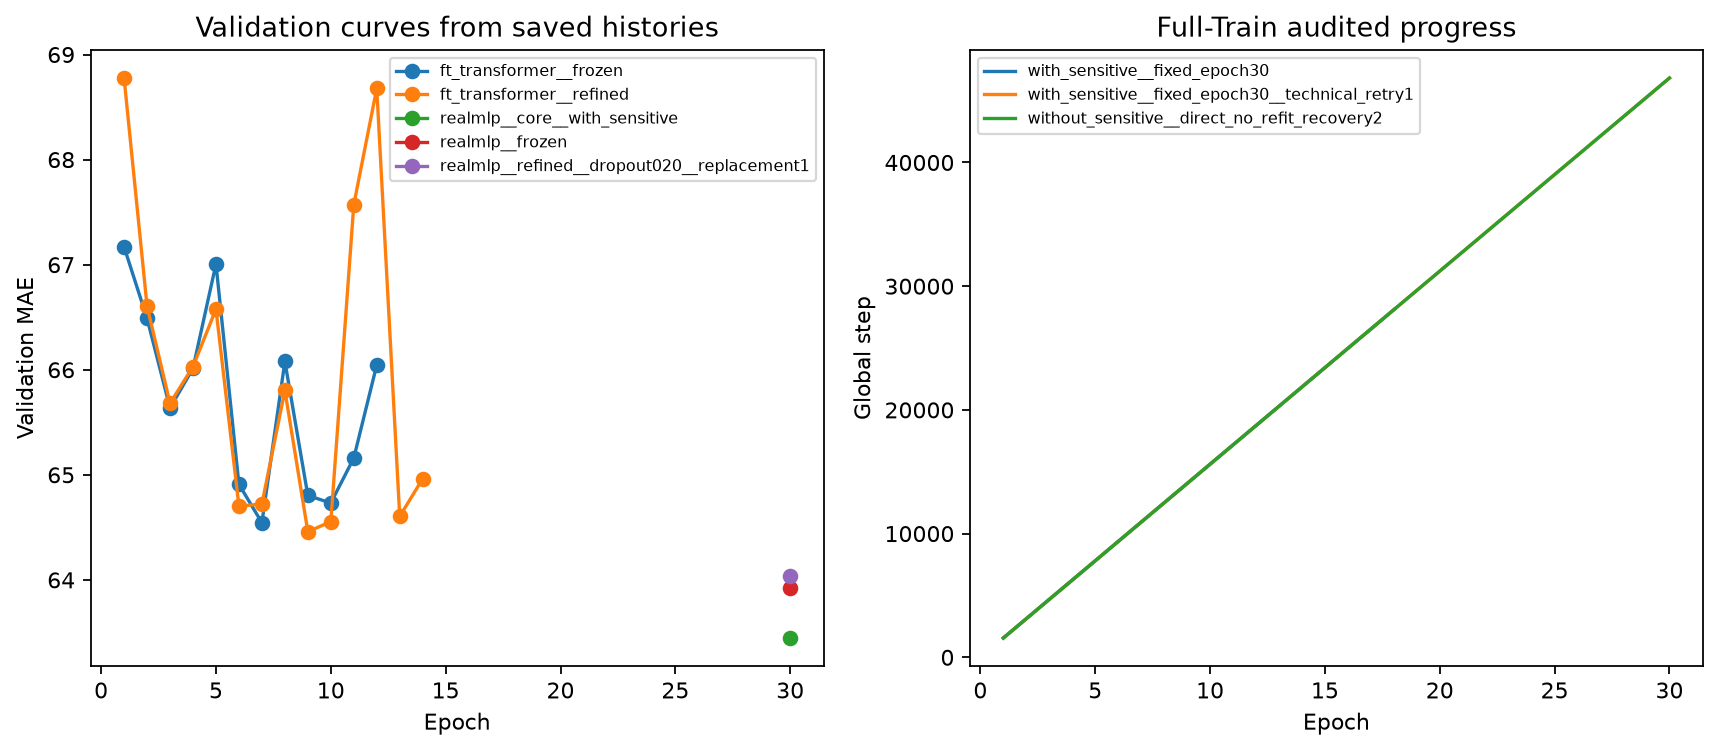

In [43]:
display(Image(filename=str(ROOT/'artifacts/figures/stage5a2/stage5a2_training_curves.png')))

### 43. Validation Error Analysis

Validation error is summarized by target decile for the two matched sensitive modes.

In [44]:
d=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/summary/stage5a2_validation_error_analysis.csv')
d

,sensitive_mode,candidate_id,target_decile,row_count,mae,rmse,mean_signed_error,p90_absolute_error,wape_percent
0,without_sensitive,stage5a2__realmlp__frozen,0,2557,27.690947,48.272708,21.827676,72.824472,85.672502
1,without_sensitive,stage5a2__realmlp__frozen,1,2474,43.577832,62.457498,33.779271,95.961201,49.690072
2,without_sensitive,stage5a2__realmlp__frozen,2,2489,38.299783,56.749590,24.243545,83.568091,31.207760
3,without_sensitive,stage5a2__realmlp__frozen,3,2525,38.824947,55.733057,16.212934,84.658114,25.549519
4,without_sensitive,stage5a2__realmlp__frozen,4,2474,41.018526,59.375247,12.010725,88.098061,22.607291
5,without_sensitive,stage5a2__realmlp__frozen,5,2535,47.535566,67.795338,3.618506,98.423926,22.145444
6,without_sensitive,stage5a2__realmlp__frozen,6,2455,51.654003,70.469969,-7.157472,104.716813,20.297974
7,without_sensitive,stage5a2__realmlp__frozen,7,2522,64.175372,82.824439,-22.395191,127.182794,20.860249
8,without_sensitive,stage5a2__realmlp__frozen,8,2472,85.403946,114.261197,-37.330264,167.237425,21.792163
9,without_sensitive,stage5a2__realmlp__frozen,9,2497,201.976265,361.784127,-139.141664,426.447466,27.703926


### 44. Runtime Summary

The runtime table includes Final Validation, sensitive Validation, both Full-Train models, and the preserved technical failure.

In [45]:
d=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/summary/stage5a2_runtime_ram_model_size_summary.csv')
d[['candidate_id','evaluation_stage','sensitive_mode','fit_time_seconds','status']]

,candidate_id,evaluation_stage,sensitive_mode,fit_time_seconds,status
0,stage5a2__realmlp__frozen,Final Validation,without_sensitive,249.093688,PASS
1,stage5a2__realmlp__refined__dropout020__replac...,Final Validation,without_sensitive,244.743950,PASS
2,stage5a2__ft_transformer__frozen,Final Validation,without_sensitive,1221.708895,PASS
3,stage5a2__ft_transformer__refined,Final Validation,without_sensitive,1177.963154,PASS
4,stage5a2__realmlp__core__with_sensitive,Sensitive Validation,with_sensitive,128.304803,PASS
5,stage5a2__realmlp__full_train__without_sensiti...,Full-Train,without_sensitive,1086.078261,PASS
6,stage5a2__realmlp__full_train__with_sensitive_...,Full-Train,with_sensitive,948.419589,PASS
7,stage5a2__realmlp__full_train__with_sensitive_...,Full-Train technical attempt,with_sensitive,NaN,TECHNICAL_FAILURE


### 45. RAM and Model-Size Summary

RAM and model sizes come from saved worker and artifact reports.

In [46]:
d=pd.read_csv(ROOT/'artifacts/results/stage5/deep_core/summary/stage5a2_runtime_ram_model_size_summary.csv')
d[['candidate_id','peak_ram_mib','model_size_bytes','bundle_size_bytes','status']]

,candidate_id,peak_ram_mib,model_size_bytes,bundle_size_bytes,status
0,stage5a2__realmlp__frozen,539.644531,970422,NaN,PASS
1,stage5a2__realmlp__refined__dropout020__replac...,629.351562,970966,NaN,PASS
2,stage5a2__ft_transformer__frozen,664.875000,2545159,NaN,PASS
3,stage5a2__ft_transformer__refined,662.269531,2545299,NaN,PASS
4,stage5a2__realmlp__core__with_sensitive,1163.597656,1016666,NaN,PASS
5,stage5a2__realmlp__full_train__without_sensiti...,1643.242188,1071174,1042628.0,PASS
6,stage5a2__realmlp__full_train__with_sensitive_...,1728.343750,1119232,1090518.0,PASS
7,stage5a2__realmlp__full_train__with_sensitive_...,1584.648438,0,0.0,TECHNICAL_FAILURE


### 46. Required Figures and Governance Registry

The required scientific figures remain unchanged. The Registry contains one idempotent governance-adjudication row after the protected 323-row prefix.

{'figures': 9, 'figure_status': 'PASS', 'registry_status': 'PASS', 'registry_rows': 324, 'governance_rows': 1, 'prior_prefix_preserved': True}


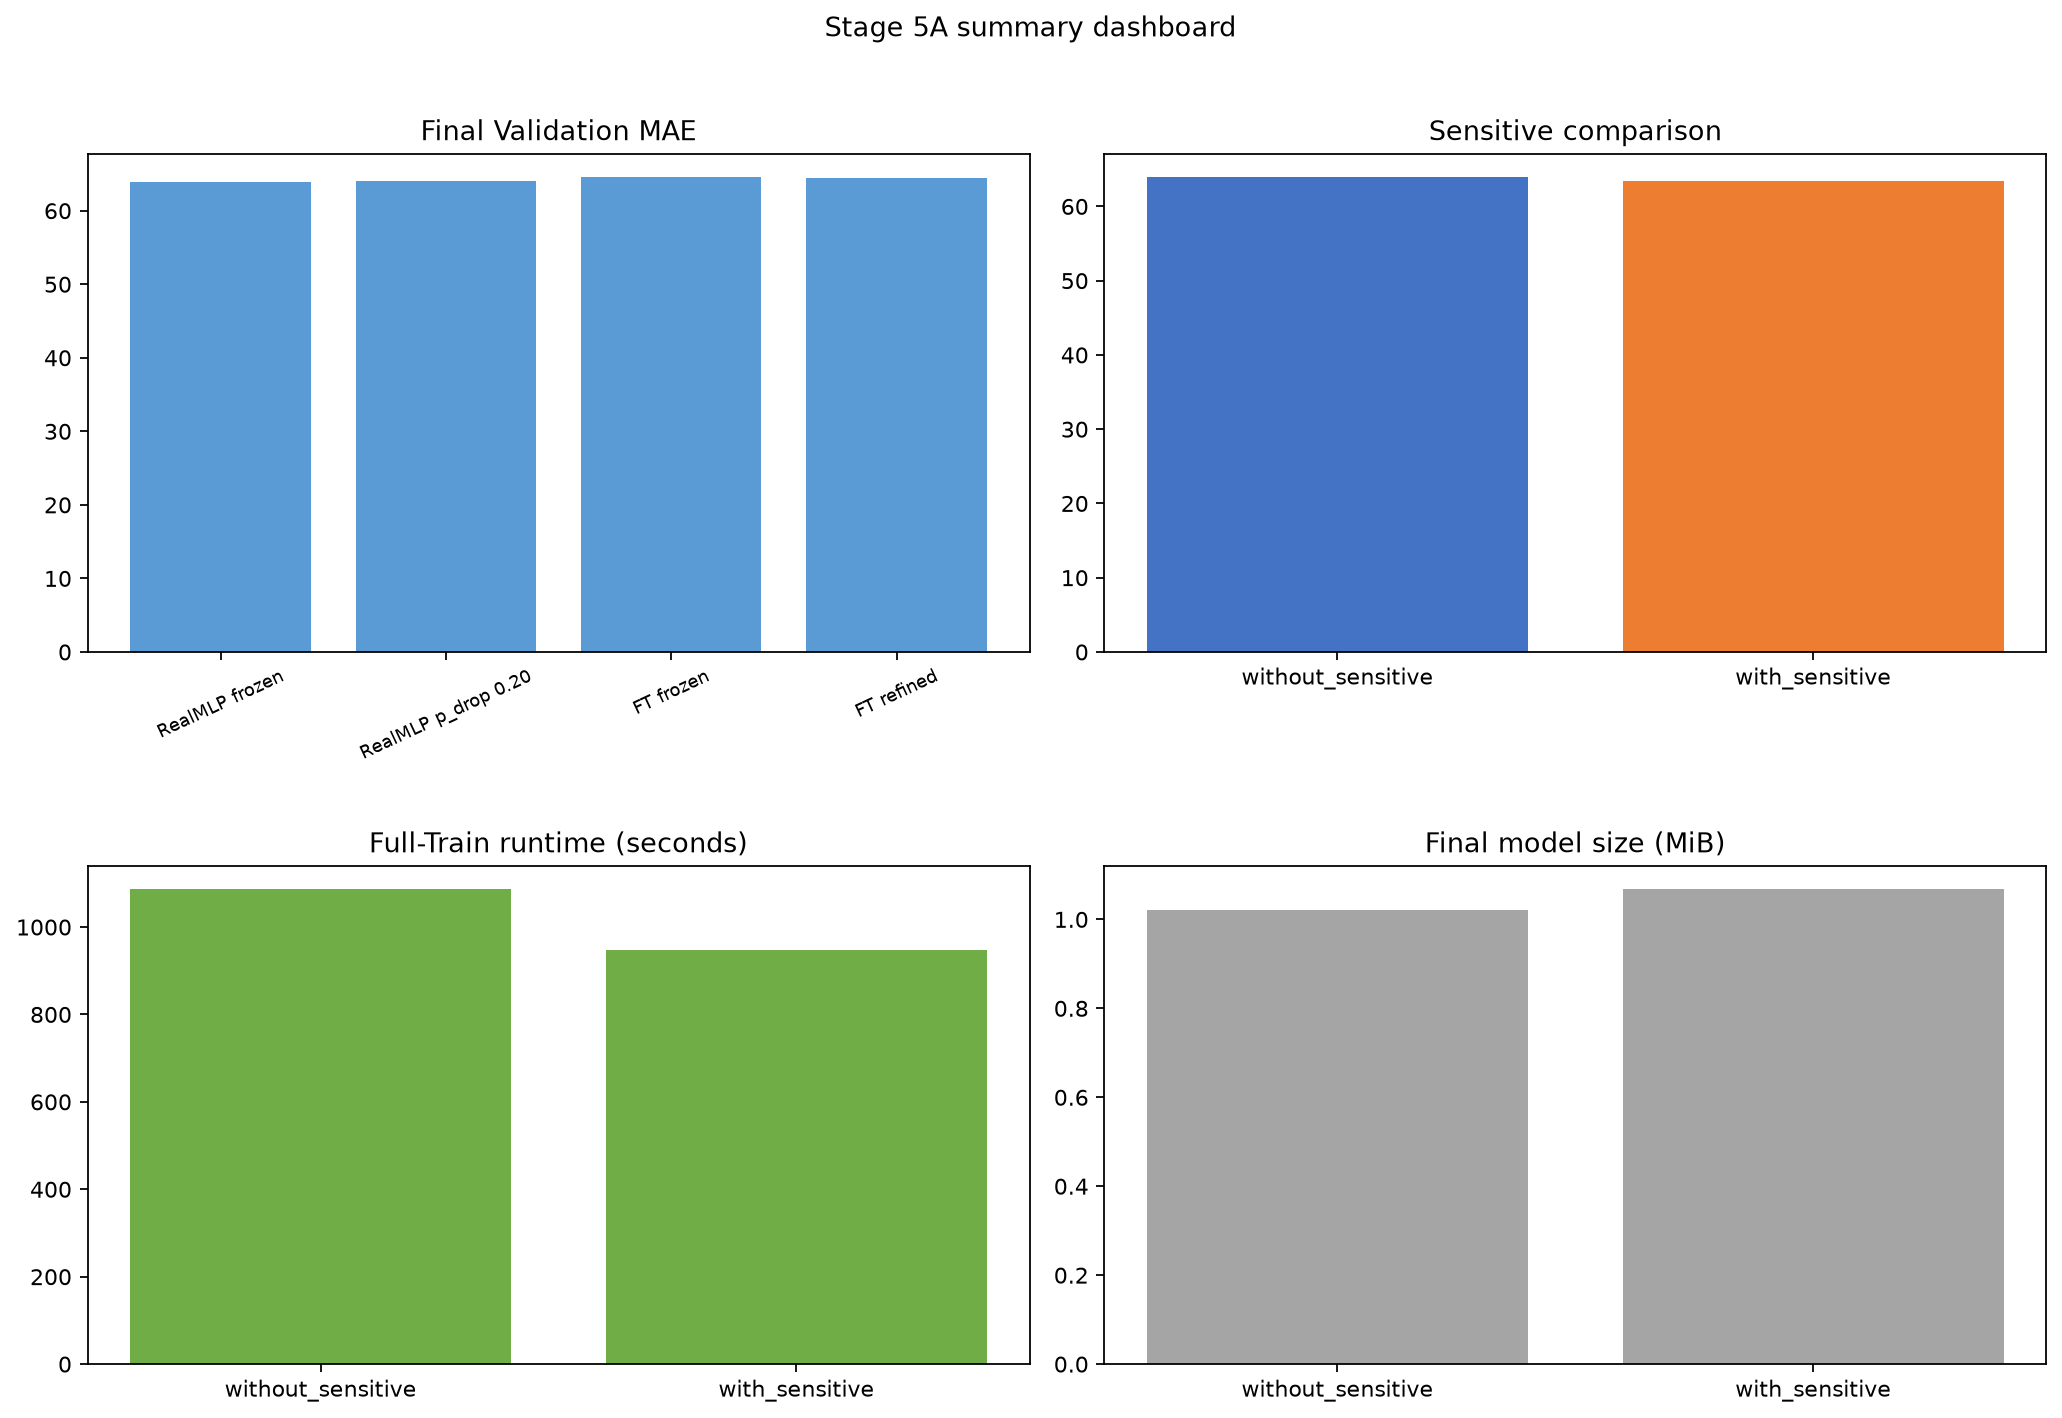

In [47]:
f=json.loads((ROOT/'artifacts/reports/stage5a2_figure_manifest.json').read_text(encoding='utf-8'))
r=json.loads((ROOT/'artifacts/reports/stage5a2_governance_registry_update.json').read_text(encoding='utf-8'))
print({'figures':len(f['figures']),'figure_status':f['status'],'registry_status':r['status'],'registry_rows':r['registry_row_count'],'governance_rows':r['governance_row_count'],'prior_prefix_preserved':r['prior_323_row_byte_prefix_preserved']})
display(Image(filename=str(ROOT/'artifacts/figures/stage5a2/stage5a_summary_dashboard.png')))

### 47. Governance Incident and Human Adjudication

The shared loader read full requested-column source chunks before it applied the saved Train-row mask. It temporarily materialized Feature and target values for 99,948 Test rows. This is a literal governance failure. The Train-only mask was applied before numerical medians, missing-value rules, categorical vocabularies, target transformation, internal RealMLP preprocessing, model fitting, selection, Validation metrics, and Validation predictions. Zero Test rows entered those learned or decision operations. No Stage 4L Test metric was used and no Stage 5 Test prediction was generated. The human adjudication accepts the incident as a limited procedural exception without demonstrated statistical leakage. Both final bundles remain valid and no refit is required.

In [48]:
g=json.loads((ROOT/'artifacts/reports/stage5a2_governance_adjudication.json').read_text(encoding='utf-8'))
s=json.loads((ROOT/'artifacts/reports/stage5a2_zero_test_loading_claim_supersession.json').read_text(encoding='utf-8'))
m=json.loads((ROOT/'artifacts/reports/stage5a2_learned_membership_audit.json').read_text(encoding='utf-8'))
u=json.loads((ROOT/'artifacts/reports/stage5a2_future_safe_loader_smoke.json').read_text(encoding='utf-8'))
print({'adjudication_id':g['adjudication_id'],'literal_zero_test_loading':g['classifications']['literal_zero_test_loading'],'procedural_compliance':g['classifications']['procedural_compliance'],'statistical_test_leakage':g['classifications']['statistical_test_leakage'],'transient_test_rows':g['test_row_count_transiently_materialized'],'preprocessing_fit_test_rows':g['preprocessing_fit_test_row_count'],'model_fit_test_rows':g['model_fit_test_row_count'],'model_selection_test_rows':g['model_selection_test_row_count'],'test_metrics_used':g['test_metric_use_count'],'stage5_test_predictions':g['stage5_test_prediction_count'],'bundle_validity':g['classifications']['bundle_validity'],'refit_required':g['classifications']['refit_required'],'superseded_literal_claims':len(s['superseded_claims']),'membership_status':m['status'],'future_loader_smoke':u['status']})

{'adjudication_id': 'stage5a2_governance_adjudication_1', 'literal_zero_test_loading': False, 'procedural_compliance': 'accepted_exception', 'statistical_test_leakage': 'not_demonstrated', 'transient_test_rows': 99948, 'preprocessing_fit_test_rows': 0, 'model_fit_test_rows': 0, 'model_selection_test_rows': 0, 'test_metrics_used': 0, 'stage5_test_predictions': 0, 'bundle_validity': 'accepted', 'refit_required': False, 'superseded_literal_claims': 8, 'membership_status': 'PASS', 'future_loader_smoke': 'PASS'}


### 48. Final Verification and Completion

Stage 5A2 and Stage 5A pass with a documented governance exception only if every scientific and artifact check passes, the literal failure stays visible, the Reviewer accepts the adjudication, no fit call occurs, protected files remain unchanged, and Stage 5B remains unstarted.

In [49]:
sys.setprofile(None)
assert RUNTIME_FIT_CALLS==[], RUNTIME_FIT_CALLS
final_path=ROOT/'artifacts/reports/stage5a_verification.json'
d=json.loads(final_path.read_text(encoding='utf-8'))
print({'stage5a_status':d['status'],'literal_zero_test_loading':'FAIL' if not d['literal_zero_test_loading'] else 'PASS','procedural_exception':d['procedural_exception'],'reviewer_status':d['reviewer_result'],'notebook_static_fit_calls':len(STATIC_FIT_CALLS),'notebook_runtime_fit_calls':len(RUNTIME_FIT_CALLS),'stage5b_started':d['stage5b_started'],'next_step':d['next_step']})

{'stage5a_status': 'PASS_WITH_DOCUMENTED_GOVERNANCE_EXCEPTION', 'literal_zero_test_loading': 'FAIL', 'procedural_exception': 'accepted_procedural_test_row_materialization_without_demonstrated_statistical_leakage', 'reviewer_status': 'PASS', 'notebook_static_fit_calls': 0, 'notebook_runtime_fit_calls': 0, 'stage5b_started': False, 'next_step': 'Begin Stage 5B — Frozen Deep and Boosting Ensemble.'}
